In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib.ticker import MaxNLocator
from scipy.interpolate import griddata
from scipy.spatial import QhullError


# ============================================================
# Paths
# ============================================================

# Top row
TOP_ROOT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/"
    + "experiments/v2.0/rf_grid"
)

# Bottom row
BOTTOM_ROOT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/"
    + "experiments/v2.0/rf_grid_conv1d"
)

OUTPUT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/"
    + "experiments/v2.0"
)

OUTPUT_PDF = OUTPUT_DIR / "rf_grid_validation_comparison.pdf"
OUTPUT_PNG = OUTPUT_DIR / "rf_grid_validation_comparison.png"


# 표시할 행 이름
TOP_ROW_LABEL = "TCD"
BOTTOM_ROW_LABEL = "Conv1d decoder"


DIR_PATTERN = re.compile(
    r"v2\.0_vctk_conv-RF=(\d+)\+text-RF=(\d+)"
)


# ============================================================
# Plot style
# ============================================================

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 12

In [2]:
def load_best_validation_results(
    root_dir: Path,
    *,
    dir_pattern: re.Pattern[str] = DIR_PATTERN,
) -> pd.DataFrame:
    """
    각 RF configuration의 eval_metrics.csv를 읽고,
    validation WBE가 가장 낮은 checkpoint를 선택합니다.

    P25는 해당 WBE-minimum checkpoint에서 가져옵니다.
    """
    if not root_dir.exists():
        raise FileNotFoundError(
            f"Experiment root does not exist: {root_dir}"
        )

    records: list[dict[str, int | float | str]] = []

    required_columns = {
        "step",
        "word_boundary_error",
        "p_word_25ms",
    }

    for exp_dir in sorted(root_dir.iterdir()):
        if not exp_dir.is_dir():
            continue

        match = dir_pattern.fullmatch(exp_dir.name)
        if match is None:
            continue

        conv_rf = int(match.group(1))
        text_rf = int(match.group(2))

        csv_path = exp_dir / "eval_metrics.csv"

        if not csv_path.exists():
            print(f"[SKIP] Missing: {csv_path}")
            continue

        df = pd.read_csv(csv_path)

        missing_columns = required_columns - set(df.columns)

        if missing_columns:
            print(
                f"[SKIP] Missing columns in {csv_path}: "
                f"{sorted(missing_columns)}"
            )
            continue

        df = (
            df[
                [
                    "step",
                    "word_boundary_error",
                    "p_word_25ms",
                ]
            ]
            .dropna(
                subset=[
                    "step",
                    "word_boundary_error",
                    "p_word_25ms",
                ]
            )
            .copy()
        )

        if df.empty:
            print(f"[SKIP] No valid rows: {csv_path}")
            continue

        # Validation WBE가 가장 낮은 checkpoint
        best_idx = df["word_boundary_error"].idxmin()
        best_row = df.loc[best_idx]

        record = {
            "experiment": exp_dir.name,
            "conv_rf": conv_rf,
            "text_rf": text_rf,
            "best_step": int(best_row["step"]),
            "wbe_ms": (
                float(best_row["word_boundary_error"])
                * 1000.0
            ),
            # WBE minimum과 동일한 checkpoint의 P25
            "p25": float(best_row["p_word_25ms"]),
        }

        records.append(record)

        print(
            f"[LOAD] {root_dir.name:20s} | "
            f"conv-RF={conv_rf:2d}, "
            f"text-RF={text_rf:2d} | "
            f"step={record['best_step']:6d} | "
            f"WBE={record['wbe_ms']:.3f} ms | "
            f"P25={record['p25']:.3f}%"
        )

    if not records:
        raise RuntimeError(
            f"No valid validation results found in {root_dir}"
        )

    result_df = pd.DataFrame(records)

    # 같은 RF 조합이 중복되었는지 검사
    duplicate_mask = result_df.duplicated(
        subset=["conv_rf", "text_rf"],
        keep=False,
    )

    if duplicate_mask.any():
        duplicates = result_df.loc[
            duplicate_mask,
            ["experiment", "conv_rf", "text_rf"],
        ]

        raise ValueError(
            "Duplicate RF configurations found:\n"
            + f"{duplicates.to_string(index=False)}"
        )

    return (
        result_df
        .sort_values(
            ["text_rf", "conv_rf"]
        )
        .reset_index(drop=True)
    )

In [3]:
top_df = load_best_validation_results(
    TOP_ROOT_DIR
)

print("\n" + "=" * 100 + "\n")

bottom_df = load_best_validation_results(
    BOTTOM_ROOT_DIR
)


print("\nTop-row results")
display(top_df)

print("\nBottom-row results")
display(bottom_df)

[LOAD] rf_grid              | conv-RF= 1, text-RF= 1 | step=162500 | WBE=23.709 ms | P25=70.331%
[LOAD] rf_grid              | conv-RF= 1, text-RF= 3 | step=133000 | WBE=23.414 ms | P25=67.694%
[LOAD] rf_grid              | conv-RF= 1, text-RF= 5 | step=173000 | WBE=23.106 ms | P25=68.581%
[LOAD] rf_grid              | conv-RF= 1, text-RF= 7 | step= 60500 | WBE=22.641 ms | P25=70.635%
[LOAD] rf_grid              | conv-RF= 1, text-RF= 9 | step= 53000 | WBE=23.014 ms | P25=69.001%
[LOAD] rf_grid              | conv-RF=11, text-RF= 1 | step=116000 | WBE=20.406 ms | P25=73.483%
[LOAD] rf_grid              | conv-RF=11, text-RF= 3 | step=164000 | WBE=20.725 ms | P25=74.556%
[LOAD] rf_grid              | conv-RF=11, text-RF= 5 | step=148000 | WBE=20.323 ms | P25=74.416%
[LOAD] rf_grid              | conv-RF=11, text-RF= 7 | step= 89000 | WBE=20.793 ms | P25=74.090%
[LOAD] rf_grid              | conv-RF=11, text-RF= 9 | step=131000 | WBE=20.598 ms | P25=73.366%
[LOAD] rf_grid              | 

,experiment,conv_rf,text_rf,best_step,wbe_ms,p25
0,v2.0_vctk_conv-RF=1+text-RF=1,1,1,162500,23.708912,70.331466
1,v2.0_vctk_conv-RF=3+text-RF=1,3,1,148000,23.152087,67.460316
2,v2.0_vctk_conv-RF=5+text-RF=1,5,1,173000,21.887988,71.661997
3,v2.0_vctk_conv-RF=7+text-RF=1,7,1,150500,20.913295,73.716152
4,v2.0_vctk_conv-RF=9+text-RF=1,9,1,155000,20.193584,75.140059
5,v2.0_vctk_conv-RF=11+text-RF=1,11,1,116000,20.406038,73.482728
6,v2.0_vctk_conv-RF=13+text-RF=1,13,1,139500,20.466929,73.459381
7,v2.0_vctk_conv-RF=15+text-RF=1,15,1,149000,20.547038,74.089634
8,v2.0_vctk_conv-RF=1+text-RF=3,1,3,133000,23.413580,67.693746
9,v2.0_vctk_conv-RF=3+text-RF=3,3,3,69000,22.874180,69.000936



Bottom-row results


,experiment,conv_rf,text_rf,best_step,wbe_ms,p25
0,v2.0_vctk_conv-RF=1+text-RF=1,1,1,162500,24.681449,68.627453
1,v2.0_vctk_conv-RF=3+text-RF=1,3,1,41500,23.306452,68.300653
2,v2.0_vctk_conv-RF=5+text-RF=1,5,1,132000,21.809399,70.751631
3,v2.0_vctk_conv-RF=7+text-RF=1,7,1,171000,22.954047,68.464053
4,v2.0_vctk_conv-RF=11+text-RF=1,11,1,40000,27.733138,59.033614
5,v2.0_vctk_conv-RF=15+text-RF=1,15,1,156000,23.779074,66.433239
6,v2.0_vctk_conv-RF=1+text-RF=3,1,3,148000,23.455473,67.366946
7,v2.0_vctk_conv-RF=3+text-RF=3,3,3,128500,22.356765,69.654530
8,v2.0_vctk_conv-RF=5+text-RF=3,5,3,119500,22.626093,70.494866
9,v2.0_vctk_conv-RF=7+text-RF=3,7,3,150500,23.531461,68.043882


In [4]:
# ============================================================
# Shared RF axes
# ============================================================

all_conv_rfs = sorted(
    set(top_df["conv_rf"].tolist())
    | set(bottom_df["conv_rf"].tolist())
)

all_text_rfs = sorted(
    set(top_df["text_rf"].tolist())
    | set(bottom_df["text_rf"].tolist())
)


conv_rf_min = min(all_conv_rfs)
conv_rf_max = max(all_conv_rfs)

text_rf_min = min(all_text_rfs)
text_rf_max = max(all_text_rfs)


# ============================================================
# Shared color ranges
# ============================================================

all_wbe = pd.concat(
    [
        top_df["wbe_ms"],
        bottom_df["wbe_ms"],
    ],
    ignore_index=True,
).to_numpy(dtype=float)

all_p25 = pd.concat(
    [
        top_df["p25"],
        bottom_df["p25"],
    ],
    ignore_index=True,
).to_numpy(dtype=float)


# 자동으로 전체 두 행의 min/max 사용
wbe_vmin = float(np.nanmin(all_wbe))
wbe_vmax = float(np.nanmax(all_wbe))

p25_vmin = float(np.nanmin(all_p25))
p25_vmax = float(np.nanmax(all_p25))


# # 필요하면 직접 범위를 지정할 수도 있음
# wbe_vmin, wbe_vmax = 20.0, 28.0
# p25_vmin, p25_vmax = 60.0, 75.0


print(
    f"WBE shared range: "
    f"{wbe_vmin:.3f} -- {wbe_vmax:.3f} ms"
)

print(
    f"P25 shared range: "
    f"{p25_vmin:.3f} -- {p25_vmax:.3f} %"
)

WBE shared range: 19.907 -- 32.372 ms
P25 shared range: 53.011 -- 75.140 %


In [5]:
def interpolate_metric_surface(
    result_df: pd.DataFrame,
    *,
    metric_column: str,
    resolution: int = 300,
    clip_min: float,
    clip_max: float,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    관측된 RF configuration을 dense surface로 보간합니다.

    cubic -> linear -> nearest 순으로 빈 영역을 보완합니다.
    """
    x = result_df["conv_rf"].to_numpy(
        dtype=float
    )
    y = result_df["text_rf"].to_numpy(
        dtype=float
    )
    z = result_df[metric_column].to_numpy(
        dtype=float
    )

    dense_x = np.linspace(
        x.min(),
        x.max(),
        resolution,
    )
    dense_y = np.linspace(
        y.min(),
        y.max(),
        resolution,
    )

    grid_x, grid_y = np.meshgrid(
        dense_x,
        dense_y,
    )

    points = np.column_stack(
        [x, y]
    )

    # Cubic interpolation은 sparse configuration에서
    # Qhull error가 날 수 있으므로 안전하게 처리
    try:
        grid_z_cubic = griddata(
            points=points,
            values=z,
            xi=(grid_x, grid_y),
            method="cubic",
        )
    except (QhullError, ValueError):
        grid_z_cubic = np.full_like(
            grid_x,
            np.nan,
            dtype=float,
        )

    try:
        grid_z_linear = griddata(
            points=points,
            values=z,
            xi=(grid_x, grid_y),
            method="linear",
        )
    except (QhullError, ValueError):
        grid_z_linear = np.full_like(
            grid_x,
            np.nan,
            dtype=float,
        )

    grid_z_nearest = griddata(
        points=points,
        values=z,
        xi=(grid_x, grid_y),
        method="nearest",
    )

    grid_z = np.where(
        np.isnan(grid_z_cubic),
        grid_z_linear,
        grid_z_cubic,
    )

    grid_z = np.where(
        np.isnan(grid_z),
        grid_z_nearest,
        grid_z,
    )

    # 보간 overshoot 방지
    grid_z = np.clip(
        grid_z,
        clip_min,
        clip_max,
    )

    return grid_x, grid_y, grid_z

In [6]:
def plot_metric_heatmap(
    ax: plt.Axes,
    result_df: pd.DataFrame,
    *,
    metric_column: str,
    cmap: str,
    vmin: float,
    vmax: float,
    optimum: str,
    show_xlabel: bool,
    show_ylabel: bool,
):
    x = result_df["conv_rf"].to_numpy(
        dtype=float
    )
    y = result_df["text_rf"].to_numpy(
        dtype=float
    )
    z = result_df[metric_column].to_numpy(
        dtype=float
    )

    grid_x, grid_y, grid_z = (
        interpolate_metric_surface(
            result_df,
            metric_column=metric_column,
            resolution=300,
            clip_min=vmin,
            clip_max=vmax,
        )
    )

    levels = np.linspace(
        vmin,
        vmax,
        100,
    )

    contour = ax.contourf(
        grid_x,
        grid_y,
        grid_z,
        levels=levels,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extend="neither",
        antialiased=True,
    )

    # 실제 평가된 configuration
    ax.scatter(
        x,
        y,
        s=32,
        marker="o",
        facecolors="none",
        edgecolors="black",
        linewidths=1.1,
        zorder=5,
    )

    # 최적 관측점
    if optimum == "min":
        best_idx = int(np.nanargmin(z))
    elif optimum == "max":
        best_idx = int(np.nanargmax(z))
    else:
        raise ValueError(
            "optimum must be 'min' or 'max'."
        )

    ax.scatter(
        x[best_idx],
        y[best_idx],
        s=145,
        marker="*",
        facecolors="white",
        edgecolors="black",
        linewidths=1.1,
        zorder=7,
    )

    ax.set_xlim(
        conv_rf_min,
        conv_rf_max,
    )
    ax.set_ylim(
        text_rf_min,
        text_rf_max,
    )

    ax.set_xticks(all_conv_rfs)
    ax.set_yticks(all_text_rfs)

    if show_xlabel:
        ax.set_xlabel(
            "Convolution RF",
            fontsize=14,
        )
    else:
        ax.set_xlabel("")
        ax.tick_params(
            axis="x",
            labelbottom=False,
        )

    if show_ylabel:
        ax.set_ylabel(
            "Text RF",
            fontsize=14,
        )
    else:
        ax.set_ylabel("")
        ax.tick_params(
            axis="y",
            labelleft=False,
        )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=12,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.25")

    return contour

Text(0.5, 1.0, 'TCD (RF=13, K=6, $\\omega_{st}=1.0$) $P_{25}$')

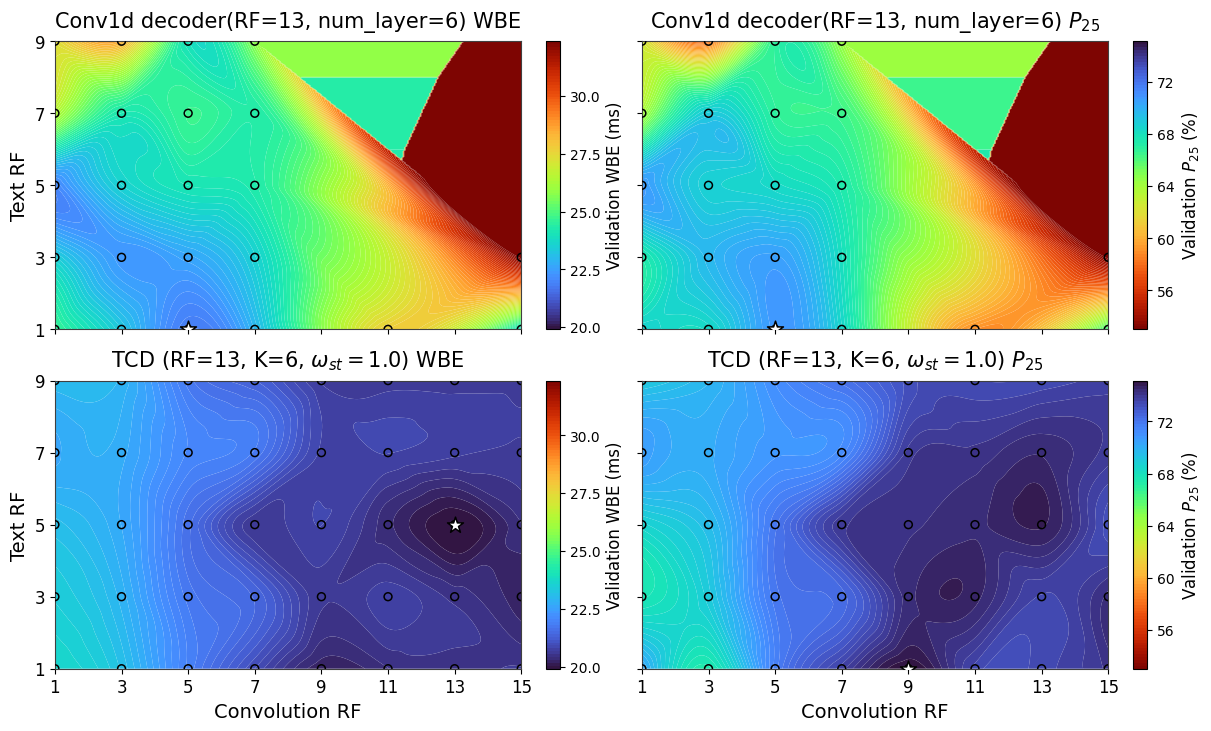

In [7]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 7.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)


# ============================================================
# Top row: rf_grid_conv1d
# ============================================================

contour_00 = plot_metric_heatmap(
    axes[0, 0],
    bottom_df,
    metric_column="wbe_ms",
    cmap="turbo",
    vmin=wbe_vmin,
    vmax=wbe_vmax,
    optimum="min",
    show_xlabel=False,
    show_ylabel=True,
)

contour_01 = plot_metric_heatmap(
    axes[0, 1],
    bottom_df,
    metric_column="p25",
    cmap="turbo_r",
    vmin=p25_vmin,
    vmax=p25_vmax,
    optimum="max",
    show_xlabel=False,
    show_ylabel=False,
)


# ============================================================
# Bottom row: rf_grid
# ============================================================

contour_10 = plot_metric_heatmap(
    axes[1, 0],
    top_df,
    metric_column="wbe_ms",
    cmap="turbo",
    vmin=wbe_vmin,
    vmax=wbe_vmax,
    optimum="min",
    show_xlabel=True,
    show_ylabel=True,
)

contour_11 = plot_metric_heatmap(
    axes[1, 1],
    top_df,
    metric_column="p25",
    cmap="turbo_r",
    vmin=p25_vmin,
    vmax=p25_vmax,
    optimum="max",
    show_xlabel=True,
    show_ylabel=False,
)



# ============================================================
# Individual colorbars (4 total)
# ============================================================

cbar_00 = fig.colorbar(
    contour_00,
    ax=axes[0, 0],
    fraction=0.046,
    pad=0.03,
)
cbar_00.set_label(
    "Validation WBE (ms)",
    fontsize=12,
)
cbar_00.ax.tick_params(
    labelsize=10,
)
cbar_00.locator = MaxNLocator(
    nbins=6
)
cbar_00.update_ticks()


cbar_01 = fig.colorbar(
    contour_01,
    ax=axes[0, 1],
    fraction=0.046,
    pad=0.03,
)
cbar_01.set_label(
    r"Validation $P_{25}$ (%)",
    fontsize=12,
)
cbar_01.ax.tick_params(
    labelsize=10,
)
cbar_01.locator = MaxNLocator(
    nbins=6
)
cbar_01.update_ticks()


cbar_10 = fig.colorbar(
    contour_10,
    ax=axes[1, 0],
    fraction=0.046,
    pad=0.03,
)
cbar_10.set_label(
    "Validation WBE (ms)",
    fontsize=12,
)
cbar_10.ax.tick_params(
    labelsize=10,
)
cbar_10.locator = MaxNLocator(
    nbins=6
)
cbar_10.update_ticks()


cbar_11 = fig.colorbar(
    contour_11,
    ax=axes[1, 1],
    fraction=0.046,
    pad=0.03,
)
cbar_11.set_label(
    r"Validation $P_{25}$ (%)",
    fontsize=12,
)
cbar_11.ax.tick_params(
    labelsize=10,
)
cbar_11.locator = MaxNLocator(
    nbins=6
)
cbar_11.update_ticks()


# ============================================================
# Column titles
# ============================================================

axes[0, 0].set_title(
    "Conv1d decoder(RF=13, num_layer=6) WBE",
    fontsize=15,
    pad=10,
)

axes[0, 1].set_title(
    r"Conv1d decoder(RF=13, num_layer=6) $P_{25}$",
    fontsize=15,
    pad=10,
)

axes[1, 0].set_title(
    r"TCD (RF=13, K=6, $\omega_{st}=1.0$) WBE",
    fontsize=15,
    pad=10,
)

axes[1, 1].set_title(
    r"TCD (RF=13, K=6, $\omega_{st}=1.0$) $P_{25}$",
    fontsize=15,
    pad=10,
)

In [172]:
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


print(f"Saved PDF: {OUTPUT_PDF.resolve()}")
print(f"Saved PNG: {OUTPUT_PNG.resolve()}")

Saved PDF: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_validation_comparison.pdf
Saved PNG: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.0/rf_grid_validation_comparison.png
